<a href="https://colab.research.google.com/github/jioring4351/hongong-ML-study/blob/main/Chapter10/10_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 대규모 언어 모델로 텍스트 생성하기

## 트랜스포머 디코더 모델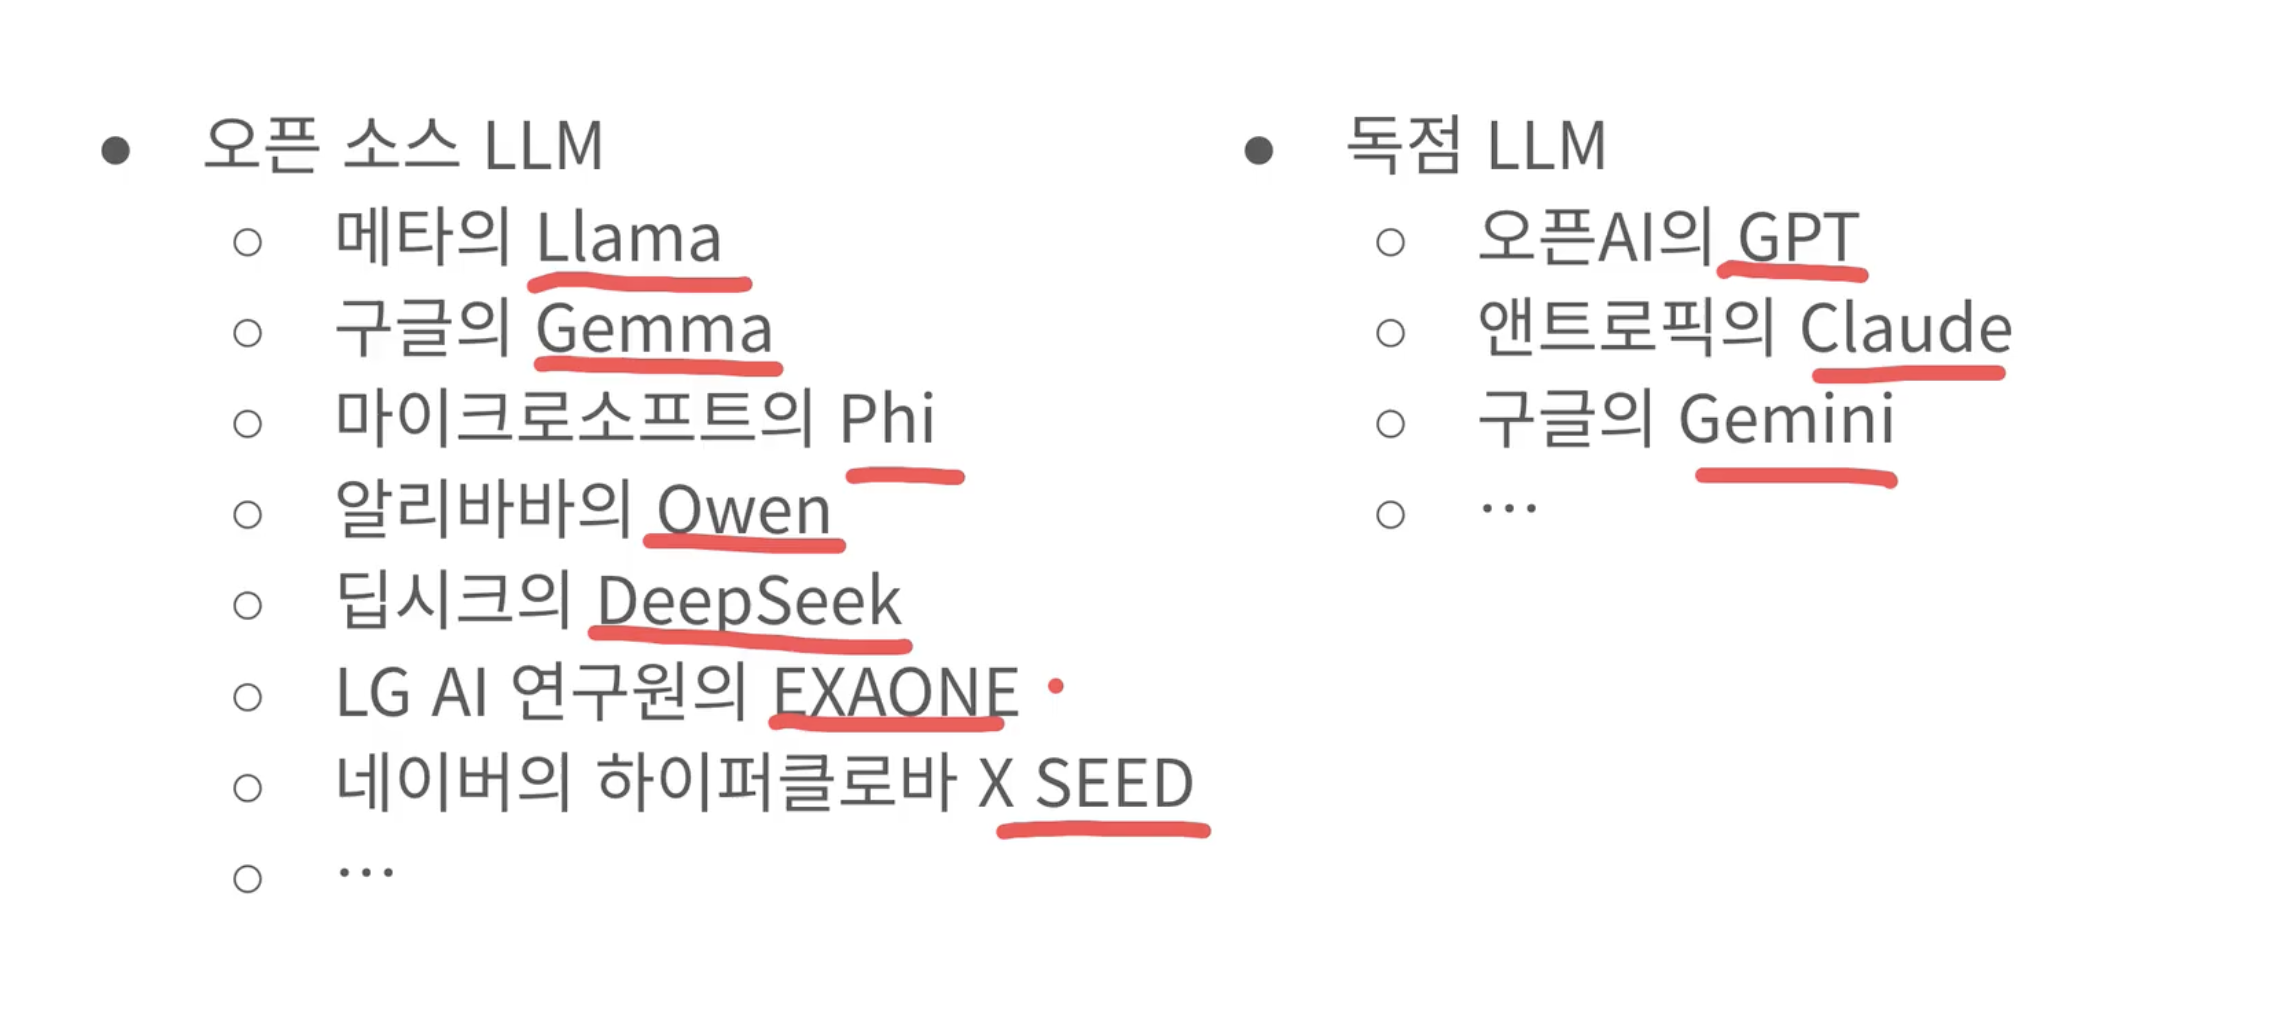

## 높은 성능을 내는 모델을 찾는 방법
### LLM 리더보드

대규모 언어 모델의 성능을 비교하는 서비스가 많다. 그중 오픈 LLM 리더보드와 LMSYS 챗봇 아레나 리더보드가 널리 알려져 있다.

리더보드를 잘 활용하면 특정 작업에 적합한 최신 모델을 쉽게 찾을 수 있다.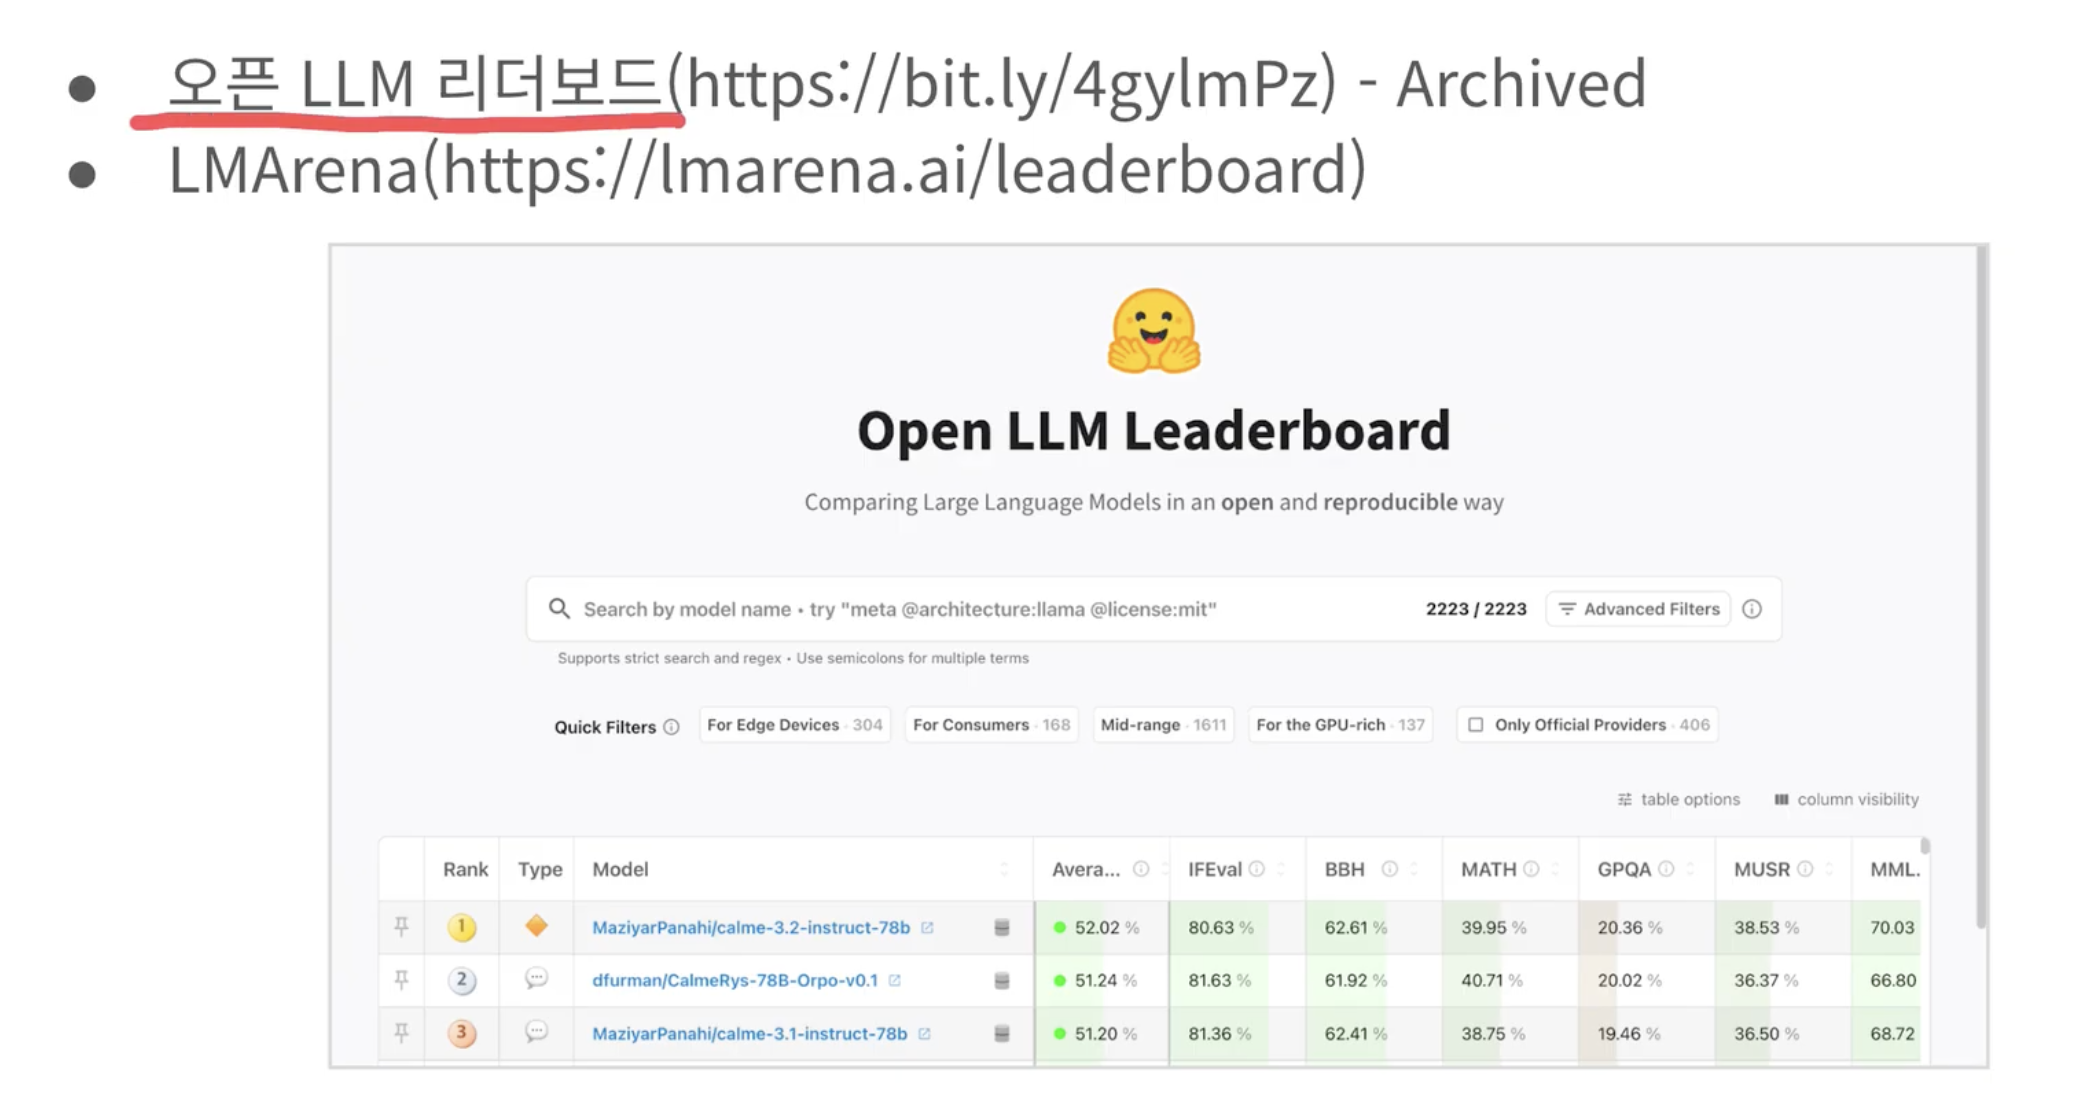

요즘 오픈 LLM 리더보드은 작동을 멈춤.

검색창에 For Edge Devices에서 파라미터 30억개 이하인 모델중 1위는 LG에서 개발한 엑사원이 차지했다.

EXAONE(엑사원)은 최신 LLM에서 널리 사용하는 그룹 쿼리 어텐션을 사용한다.

## 멀티 쿼리 vs 그룹 쿼리 어텐션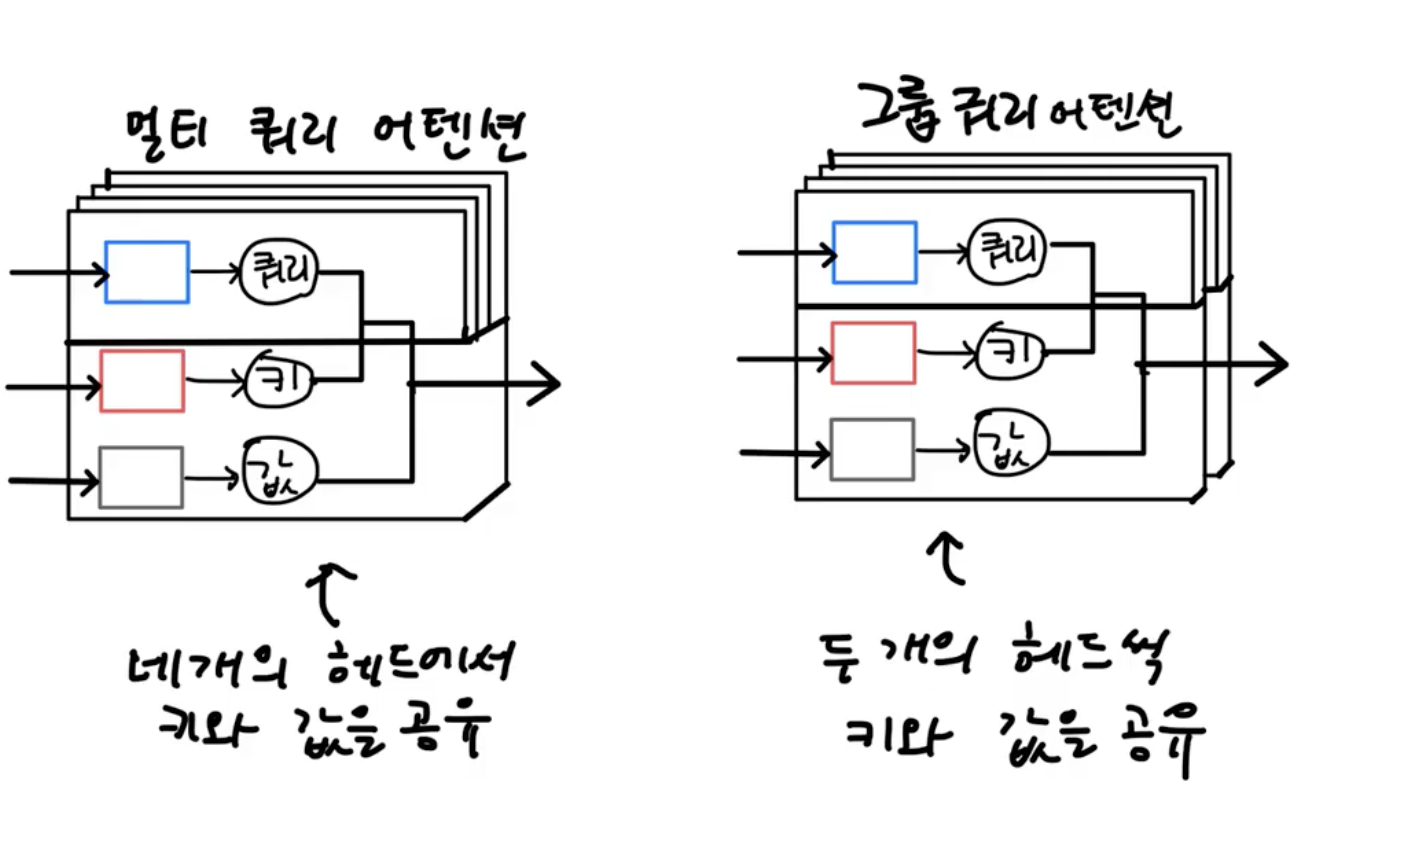

기존에는 멀티 헤드 어텐션으로 디코더는 하나의 토큰을 생성한 후 그 토큰을 입력의 끝에 이어 붙인 다음 다시 모델에 입력해 다음 토큰을 생성하는데 이를 자기회귀 모델이라 부른다. 이 방식은 디코더가 하나의 토큰을 생성할 때마다 이전에 처리했던 토큰들을 매번 다시 계산해야 하므로, 언뜻보면 계산 낭비처럼 보인다. 그래서 어텐션 층에서 키와 값을 캐시에 저장하고 다음 토큰을 생성할 때 재사용하는 기법이 등장했지만 트랜스포머에 입력할 수 있는 최대 입력 길이를 늘릴려면 캐시의 크기도 자연스럽게 커진다.

이런 문제를 해결하기 위해 멀티 헤드 어텐션에서 키와 값을 모든 헤드에서 공유하는 방식이 등장했고 이를 멀티 쿼리 어텐션이라 부른다.

그리고 모든 헤드에서 키와 값을 공유하지 않고, 몇 개의 헤드씩 나눠서 공유하는 방식이 그룹 쿼리 어텐션이다.

멀티 쿼리 어텐션과 그루부 쿼리 어텐션은 키와 값을 만드는 밀집층의 개수가 줄어들기 때문에 전체 모델의 파라미터 개수를 줄이는 효과도 있다.

## SwiGLU 활성화
실수 함수는 어텐션 층 다음에 등장하는 피드포워드 네트워크에서 최근 LLM 에서 많이 사용되는 활성화 함수이다.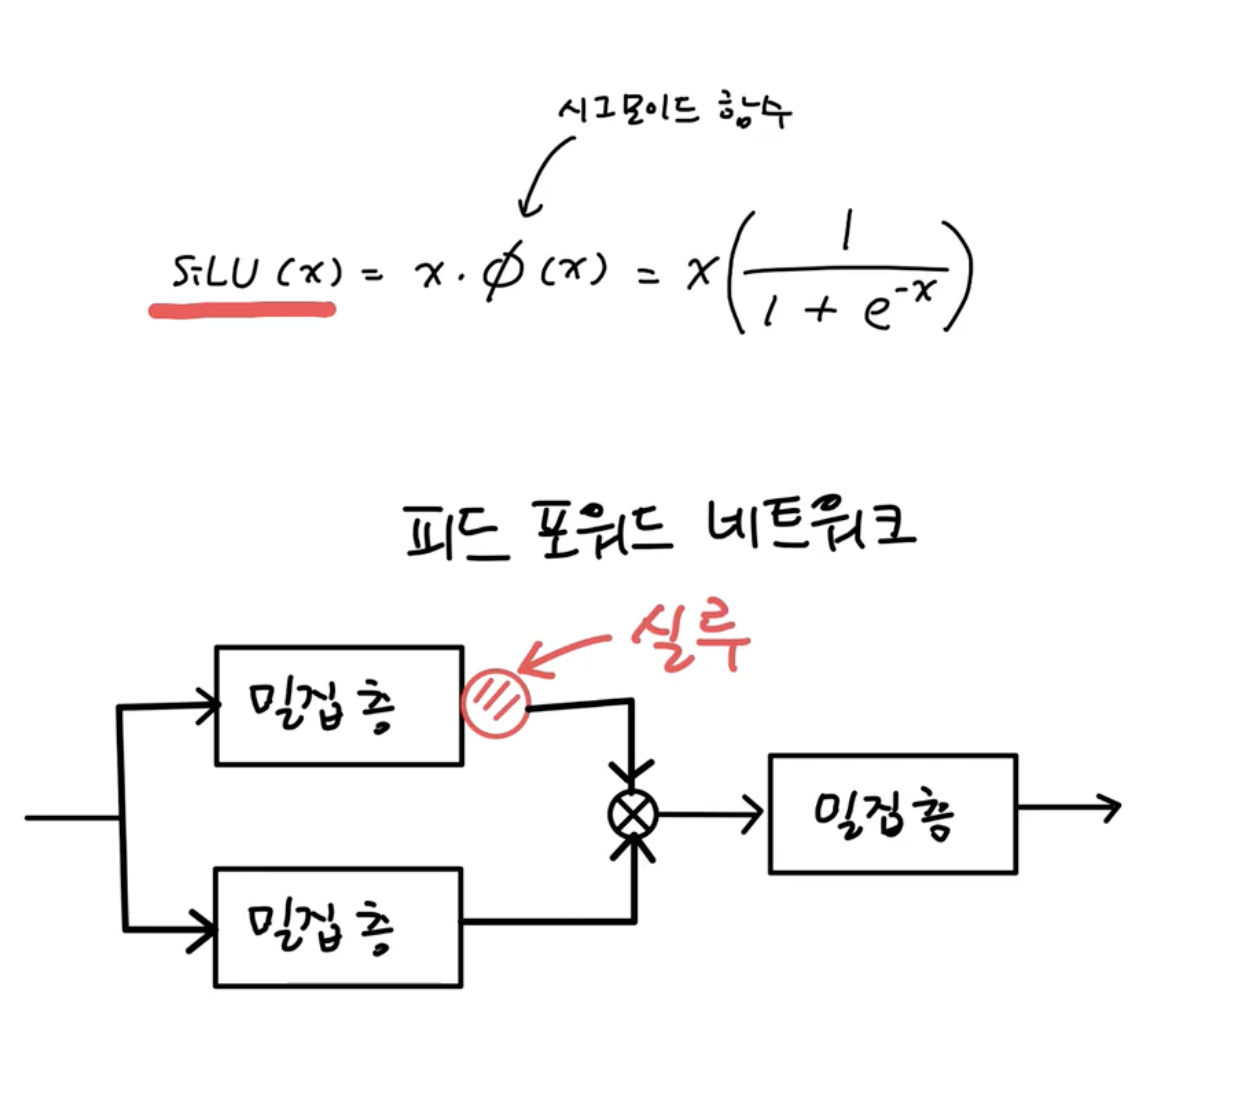

이 함수는 밀집층의 출력에 시그모이드 함수를 적용한 다음 이 결과에 원래 출력을 다시 곱한다.

젤루와 마찬가지로 원점에서도 미분 가능.

피드포워드 네트워크의 첫 번째 밀집층을 두 개로 나누어 하나는 실루 함수를 적용하고, 다른 하나는 활성화 함수를 적용하지 않는다.

## RMS 정규화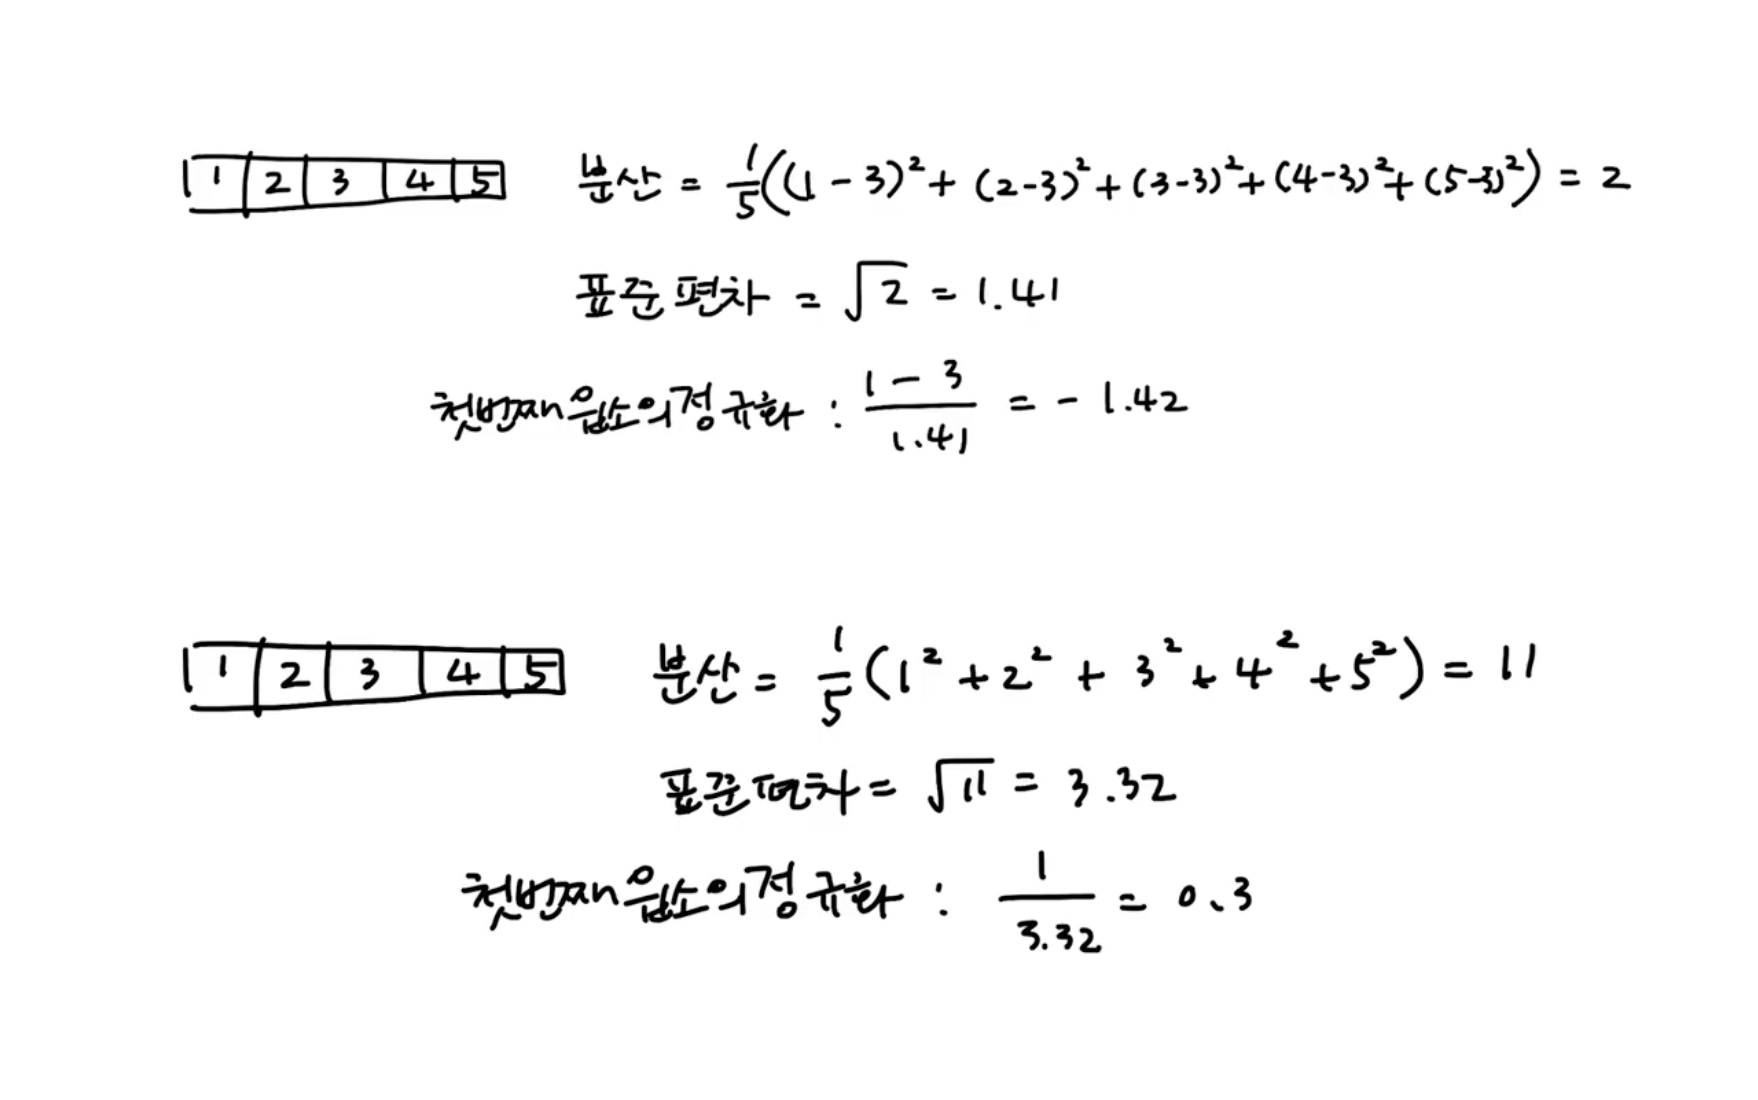

층 정규화의 변종이다.

정규화 할 때 평균을 구하지 않는 방법이다.

입력에서 평균을 뺴지 않고, 표준편차를 구할 때도 평균을 사용하지 않는 방법이 RMS 정규화이다.

방법은 위 그림에서 아래 방법과 같다.

이 방법을 사용하면 평균을 계산하지 않아도 되므로 계산 속도가 빠르다.

최근 LLM은 이런 정규화를 어텐션 층 다음이 아닌 어텐션 이전에 두는 경항이 있다.

## EXAONE 으로 대답 생성하기

In [4]:
#엑사온 모델 생성
from transformers import pipeline

model_name = "LGAI-EXAONE/EXAONE-4.0-1.2B"

pipe = pipeline(
    task="text-generation",
    model=model_name,
    trust_remote_code=True,
    device=0
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.56G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/332 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

In [16]:
#채팅 템플릿 구성
messages = [
    {"role": "system",
     "content": "너는 쇼핑몰 홈페이지에 올라온 질문에 대답하는 Q&A 챗봇이야. \
                확정적인 답변을 하지 말고 제품 담당자가 정확한 답변을 하기 위해 \
                시간이 필요하다는 간단하고 친절한 답변을 생성해줘."},
                 {"role": "user", "content": "이 다이어리에 내년도 공휴일이 표시되어 있나요?"}
]

In [17]:
#파이프라인 객체 호출
pipe(messages, max_new_tokens=200)

Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': [{'role': 'system',
    'content': '너는 쇼핑몰 홈페이지에 올라온 질문에 대답하는 Q&A 챗봇이야.                 확정적인 답변을 하지 말고 제품 담당자가 정확한 답변을 하기 위해                 시간이 필요하다는 간단하고 친절한 답변을 생성해줘.'},
   {'role': 'user', 'content': '이 다이어리에 내년도 공휴일이 표시되어 있나요?'},
   {'role': 'assistant',
    'content': '네, 다이노리에 홈페이지에는 매년 변하는 공휴일과 기념일이 표시되어 있습니다. 제가 가장 최신 정보를 확인하지는 않았지만, 직접 검색해 보니 내년도 12월 25일은 크리스마스 트리 빛 축제가 있을 예정이네요. 제품에 따라 특별 이벤트가 있을 수도 있으니 확인해 보시는 건 어떨까요? 😊'}]}]

In [18]:
#모델이 생성한 텍스트만 출력하기 (500자로)
pipe(messages, max_new_tokens=500, return_full_text = False)

Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': '안녕하세요! 다이어리의 annually updated 공휴일 표시 여부는 최근에 변경되었는지 확인이 필요해요. 제품 담당자께서 확인 후 바로 알려드리겠습니다! 😊 추가로 궁금한 점이 있으면 편하게 물어보세요.'}]

In [9]:
#조금 확률적으로 토큰을 선택하기(조금 더 자연스러운 답변)
output = pipe(messages, max_new_tokens=200, return_full_text=False,
              do_sample = True)
print(output[0]['generated_text'])

Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


네, 해당 다이어리에는 내년도 주요 공휴일이 추가로 표시되어 있습니다! 제품 specifications을 확인해 보시고, 더 자세한 내용은 담당 담당자에게 알려드릴게요. 😊


## 토큰 디코딩 전략

지금까지 LLM 모델의 디코더가 출력하는 값을 확률이라 설명했는데 실제로 디코더가 출력하는 것은 확률이 아니라 각 토큰에 대한 점수이다.

이 점수에 소프트맥스 함수를 적용하면 확률로 변환할 수 있다. 보통 소프트맥스 함수를 적용하기 전의 값을 로짓이라고 부른다.

가장 확률이 높은 토큰을 뽑는게 합리적처럼 보이지만 그렇게 하면 자연스럽지 못한 답이 나올수 있음. 그렇기에 출력되는 토큰의 확률을 조정하는 방법을 토큰 디코딩 전략이라 부른다.

가장 간단한 디코딩 방식은 do_sample 매개변수가 기본값 False일 떄다. 이 경우 가장 높은 확률을 가진 토큰 하나를 선택하기 때문에 프롬프트가 같으면 모델을 여러 번 실행해도 항상 같은 대답을 얻을 수 있다. 이런 전략을 그리디 서치라 부른다.

트랜스포머 패키지는 기본적으로 그리디 서치를 사용하며 매개변수르 True로 설정하면 샘플링 전략이 가능하다. 가장 널리 사용하는 방식은 top-k, top-p 샘플링이다.

## 기본샘플링

In [10]:
#디코더가 출력ㅎ나 로짓 중에서 한 토큰의 로짓이 아주 크다고 가정
import numpy as np

logits = np.array([1, 2, 3, 4, 100])

In [11]:
#소프트맥스 함수 통과(마지막 수가 거의 1)
from scipy.special import softmax
probas = softmax(logits)
print(probas)

[1.01122149e-43 2.74878501e-43 7.47197234e-43 2.03109266e-42
 1.00000000e+00]


In [12]:
#로짓에서 각 수의 확률 실험(100번)
np.random.multinomial(100, probas)

array([  0,   0,   0,   0, 100])

In [13]:
#소프트맥스가 만드는 확률 분포를 조금 변형 시켜주기(여전히 마지막이 많이 뽑히지만 나머지도 어느정도 선택됨)
probas = softmax(logits/100)
np.random.multinomial(100, probas)

array([22, 19, 17, 13, 29])

위처럼 100으로 나눠주면 즉, 1보다 큰값으로 나눠주면 확률 분포가 조금 더 부드러워져 다른 원소가 선택될 가능성이 높아짐.

반대로 1보다 작은 수로 나누면 확률 분포가 더 결정적으로 바뀌고 가장 큰 로짓을 선택한느 그리디 서치와 비슷하게 동작함

이렇게 선택의 다양성을 증가시키거나 줄이는 역할을 하는 이 값을 온도 파라미터라 부름.

In [14]:
#온도를 높였을때(토큰의 선택 가능성을 고르게 부여하다 보니 적절하지 않은 토큰이 많이 선택된다.)
output = pipe(messages, max_new_tokens=200, return_full_text=False,
              do_sample=True, temperature=10.0)
print(output[0]['generated_text'])

Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


안녕한 여러분이니까 확인 도움 되도록 하기 소요됟은 이야기하더면 이해하시겠다로예⚰ 생각하고 나서 차근차근 조언 드리자 들시는 편입니다💓   작인 설명 하나와 후박 드릴게요!현재 Our Durablepaper 노트 위주의 사용자님 기준 해당 계절정보 적용 주기등 보통 구매님의 선호 기간 대비 가장 인기 많디던 방식인서시월이 출제적이면 대개순 공휴일 기재를 완료하중한다 고하여 확인 요청 드릴 경우 대부분 직접 입력 체험해 보세요 미리 예경진 도와진다네 기능 이해하고 저하나 기록 등 참고해도 필요시 방문판매센터 전화시간인너 좋시다 ✨ ]>> 사용 시기 안내드려네요 직접 스크롤 혹은담 서면 기재가 원하시고, 미리 예약 체험하기 원하셔야합니다 또한 자세시 불름드 정확해지나면 반드시 당일 클릭식 조작 후 시스템 동기izations를 요청실수년인용용 점검 과정엔 시간여 필요한


In [15]:
#온도를 낮췄을때
output = pipe(messages, max_new_tokens=200, return_full_text=False,
              do_sample=True, temperature=0.001)
print(output[0]['generated_text'])

Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


네, 해당 다이어리에는 내년도 주요 공휴일이 미리 표시되어 있어요!  
(2024년 기준으로 12월 25일 크리스마스, 1월 1일 설날, 3월 15일 삼순절 등이 포함되어 있습니다.)  

하지만 정확한 날짜나 추가 공휴일은 제품 변경 요청이나 담당자와 상담하시면 더 자세히 알려드릴 수 있어요. 😊


## top-k 샘플링
모델이 출력한 로짓을 기준으로 최상위 k개의 토큰을 선택하는 방법. 이후 선택된 토큰의 로짓만 소프트맥스 함수에 통과시킴.

쉽게 말해 가능성이 높은 몇 개의 토큰 중에서 하나를 선택하는 방법.

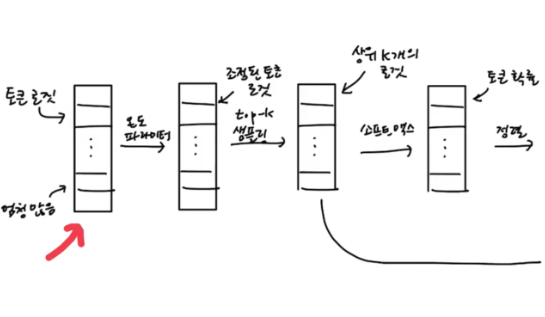

In [19]:
#top-k
output = pipe(messages, max_new_tokens=200, return_full_text=False,
              do_sample=True, top_k =10)
print(output[0]['generated_text'])

Passing `generation_config` together with generation-related arguments=({'do_sample', 'top_k', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


물론이죠! 다이어리에 내년도 공휴일이 표시되어 있는지 확인할 수 없어요. 제품 담당자님께서 확인해 주시겠어요? 😊


In [20]:
#top-k 에 온도를 높여보기(온도로 로짓이 작은 토큰들의 선택 가능성을 높였지만, top-k를 사용해 최상위 토큰만 선택한 결과)
output = pipe(messages, max_new_tokens=200, return_full_text=False,
              do_sample=True, top_k =10, temperature = 10.0)
print(output[0]['generated_text'])

Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'top_k', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


네요? 그 부분 좀 다시 말씀드릴래요! 📅 다음 공휴일 목록은 항상 최신화 되니 언제든지 업데이트되니까 편하세요~ 확인하시기전이에 whichever 대로 말씀해 드릴게요! (추가 질문 원하셔도 돼요)


##top-p

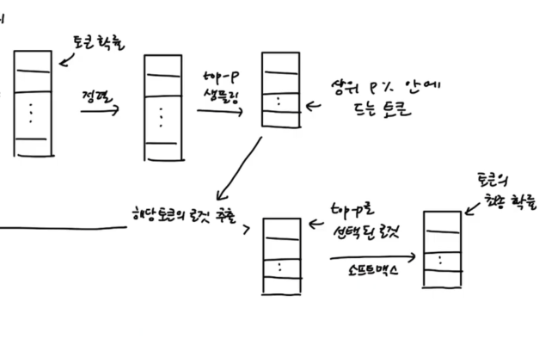

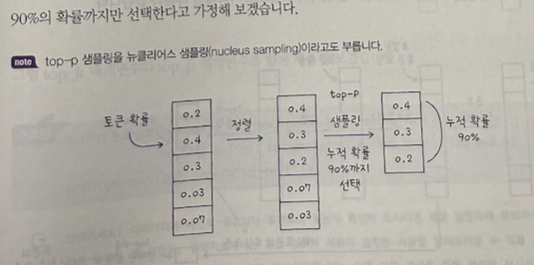

In [21]:
#top-p(90%로 지정했다는 것은 LLM이 다음 토큰을 선택할 때 모두 합쳐서 90% 확률 안에 드는 토큰만을 사용했다는 의미이다.)
output = pipe(messages, max_new_tokens=200, return_full_text=False,
              do_sample=True, top_p=0.9)
print(output[0]['generated_text'])

Passing `generation_config` together with generation-related arguments=({'do_sample', 'top_p', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


네, 해당 다이어리에는 내년도 공휴일이 함께 표시되어 있어요! 새로 구매하시는 분들께서는 구매 페이지에서 확인해 주시면 바로 알려드릴게요 😊


## top-p와 top-p를 같이 사용했을때 전체 진행과정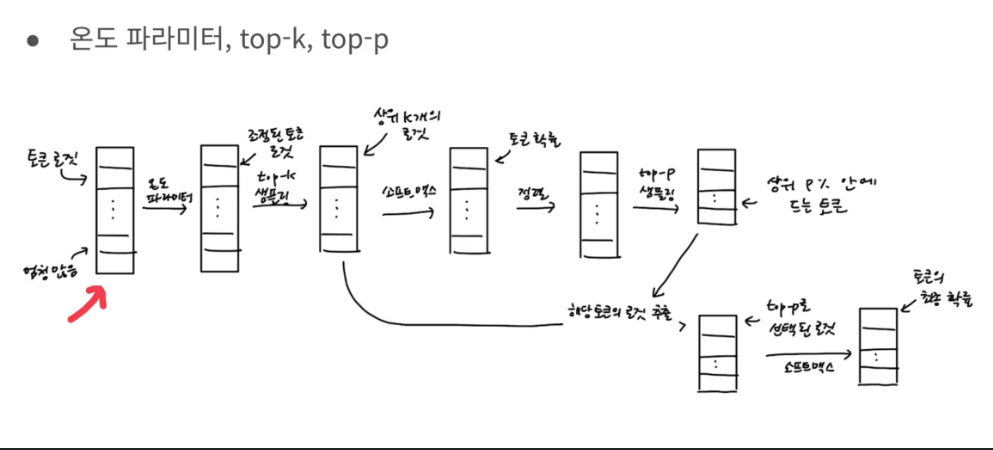

top-p만 쓰면 계산량이 늘어나는 단점이 있기에 top-k로 먼저 최상위로짓을 일부 선택한 다음 top-p방식을 적용하여 계산량을 낮춘다.

In [22]:
#top-k, top-p 같이 사용하기
output = pipe(messages, max_new_tokens=200, return_full_text=False,
              do_sample=True, temperature=2.0, top_k=100, top_p=0.9)
print(output[0]['generated_text'])

Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'top_k', 'top_p', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


제품 전용 게시판 페이지에서 보면 가장 가까운 다음 year의 시즌 패스까지 연장해 놓어 주셨거든요! 조금은 기다려주insta되어 드릴게요✨ 구체적인 작동방식충해서 한번 한번 visible이 될지 말씀해 주세요 😉
